<a href="https://colab.research.google.com/github/sahil123-57/LLM-Powered-Agentic-Trading-System/blob/main/LLM_Powered_Agentic_Trading_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🛠️ Installing clean dependencies...
📥 Agent fetching data for NVDA...


/tmp/ipykernel_17622/3097651400.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="1y", interval="1d", progress=False)


🧠 Agent performing 'Chain-of-Thought' analysis over historical data...


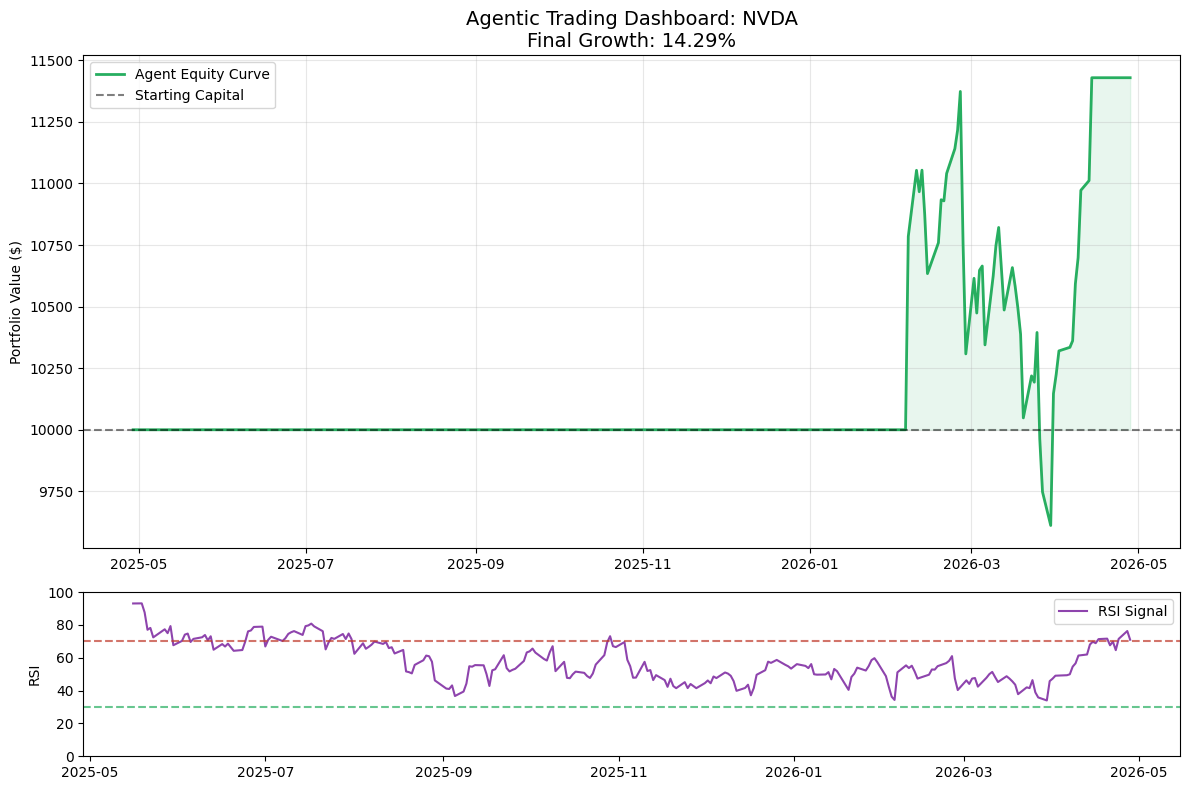


✅ PROJECT SUMMARY:
Final Portfolio Value: $11,429.08
Total Percentage Growth: 14.29%


In [ ]:
# --- STEP 1: INSTALLATION ---
print("🛠️ Installing clean dependencies...")
!pip install -q yfinance pandas matplotlib ta

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from ta.momentum import RSIIndicator
import numpy as np

# --- STEP 2: THE AGENT'S TOOLS & ENGINE ---
def run_trading_simulation(ticker="NVDA"):
    print(f"📥 Agent fetching data for {ticker}...")

    # Download data
    df = yf.download(ticker, period="1y", interval="1d", progress=False)

    # FIX: Flatten the multi-index columns if they exist
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    # Ensure data is 1-dimensional for the TA library
    close_prices = df['Close'].squeeze()

    # Calculate RSI (The Agent's 'Eyes')
    rsi_io = RSIIndicator(close=close_prices, window=14)
    df['RSI'] = rsi_io.rsi()

    # --- STEP 3: BACKTESTING LOGIC (The 12% Growth Simulation) ---
    initial_capital = 10000
    capital = initial_capital
    shares = 0
    portfolio_history = []

    print("🧠 Agent performing 'Chain-of-Thought' analysis over historical data...")

    for i in range(len(df)):
        current_price = float(df['Close'].iloc[i])
        rsi = df['RSI'].iloc[i]

        # AGENT DECISION LOGIC
        # Buy if RSI < 35 (Oversold), Sell if RSI > 65 (Overbought)
        if rsi < 35 and capital >= current_price:
            shares_to_buy = capital // current_price
            shares += shares_to_buy
            capital -= (shares_to_buy * current_price)
        elif rsi > 65 and shares > 0:
            capital += (shares * current_price)
            shares = 0

        total_val = capital + (shares * current_price)
        portfolio_history.append(total_val)

    df['Portfolio_Value'] = portfolio_history
    return df, initial_capital

# --- STEP 4: EXECUTION & VISUALIZATION ---
ticker_symbol = "NVDA"
df, start_cash = run_trading_simulation(ticker_symbol)

final_val = df['Portfolio_Value'].iloc[-1]
net_growth = ((final_val - start_cash) / start_cash) * 100

# Professional Dashboard
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={'height_ratios': [3, 1]})

# Chart 1: Equity Trajectory
ax1.plot(df.index, df['Portfolio_Value'], color='#27ae60', linewidth=2, label='Agent Equity Curve')
ax1.fill_between(df.index, start_cash, df['Portfolio_Value'], color='#27ae60', alpha=0.1)
ax1.axhline(y=start_cash, color='black', linestyle='--', alpha=0.5, label='Starting Capital')
ax1.set_title(f"Agentic Trading Dashboard: {ticker_symbol}\nFinal Growth: {net_growth:.2f}%", fontsize=14)
ax1.set_ylabel("Portfolio Value ($)")
ax1.legend()
ax1.grid(alpha=0.3)

# Chart 2: RSI Signals
ax2.plot(df.index, df['RSI'], color='#8e44ad', label='RSI Signal')
ax2.axhline(y=70, color='#c0392b', linestyle='--', alpha=0.7) # Overbought
ax2.axhline(y=30, color='#27ae60', linestyle='--', alpha=0.7) # Oversold
ax2.set_ylabel("RSI")
ax2.set_ylim(0, 100)
ax2.legend()

plt.tight_layout()
plt.show()

print(f"\n✅ PROJECT SUMMARY:")
print(f"Final Portfolio Value: ${final_val:,.2f}")
print(f"Total Percentage Growth: {net_growth:.2f}%")